In [1]:
import pandas as pd
import numpy as np

In [ ]:
hd=pd.read_excel(r"C:\Users\anadi\Desktop\Heart disease-Ctree.xlsx")

In [15]:
hd.shape

(303, 10)

In [17]:
hd.head()

,Age,Sex,Chest Pain,trestbps,chol,fbs,thalach,exang,oldpeak,Heart Disease
0,63,Male,cp1,145,233,no,150,no,2.3,no
1,67,Male,cp4,160,286,no,108,yes,1.5,yes
2,67,Male,cp4,120,229,no,129,yes,2.6,yes
3,37,Male,cp3,130,250,no,187,no,3.5,no
4,41,Female,cp2,130,204,no,172,no,1.4,no


In [19]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            303 non-null    int64  
 1   Sex            303 non-null    object 
 2   Chest Pain     303 non-null    object 
 3   trestbps       303 non-null    int64  
 4   chol           303 non-null    int64  
 5   fbs            303 non-null    object 
 6   thalach        303 non-null    int64  
 7   exang          303 non-null    object 
 8   oldpeak        303 non-null    float64
 9   Heart Disease  303 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 23.8+ KB


In [21]:
hd_cat=dm.select_dtypes(object)

In [23]:
hd_num=dm.select_dtypes(int)

In [25]:
hd_num

,Age,trestbps,chol,thalach
0,63,145,233,150
1,67,160,286,108
2,67,120,229,129
3,37,130,250,187
4,41,130,204,172
...,...,...,...,...
298,45,110,264,132
299,68,144,193,141
300,57,130,131,115
301,57,130,236,174


In [27]:
hd_cat

,Sex,Chest Pain,fbs,exang,Heart Disease
0,Male,cp1,no,no,no
1,Male,cp4,no,yes,yes
2,Male,cp4,no,yes,yes
3,Male,cp3,no,no,no
4,Female,cp2,no,no,no
...,...,...,...,...,...
298,Male,cp1,no,no,yes
299,Male,cp4,yes,no,yes
300,Male,cp4,no,yes,yes
301,Female,cp2,no,no,yes


In [29]:
dummies = pd.get_dummies(hd_cat)

In [31]:
dummies

,Sex_Female,Sex_Male,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes,Heart Disease_no,Heart Disease_yes
0,False,True,True,False,False,False,True,False,True,False,True,False
1,False,True,False,False,False,True,True,False,False,True,False,True
2,False,True,False,False,False,True,True,False,False,True,False,True
3,False,True,False,False,True,False,True,False,True,False,True,False
4,True,False,False,True,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,True,True,False,False,False,True,False,True,False,False,True
299,False,True,False,False,False,True,False,True,True,False,False,True
300,False,True,False,False,False,True,True,False,False,True,False,True
301,True,False,False,True,False,False,True,False,True,False,False,True


In [43]:
hd1=pd.concat([hd,dummies],axis="columns")

In [45]:
hd1.head()

,Age,Sex,Chest Pain,trestbps,chol,fbs,thalach,exang,oldpeak,Heart Disease,...,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes,Heart Disease_no,Heart Disease_yes
0,63,Male,cp1,145,233,no,150,no,2.3,no,...,True,False,False,False,True,False,True,False,True,False
1,67,Male,cp4,160,286,no,108,yes,1.5,yes,...,False,False,False,True,True,False,False,True,False,True
2,67,Male,cp4,120,229,no,129,yes,2.6,yes,...,False,False,False,True,True,False,False,True,False,True
3,37,Male,cp3,130,250,no,187,no,3.5,no,...,False,False,True,False,True,False,True,False,True,False
4,41,Female,cp2,130,204,no,172,no,1.4,no,...,False,True,False,False,True,False,True,False,True,False


In [47]:
hd1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                303 non-null    int64  
 1   Sex                303 non-null    object 
 2   Chest Pain         303 non-null    object 
 3   trestbps           303 non-null    int64  
 4   chol               303 non-null    int64  
 5   fbs                303 non-null    object 
 6   thalach            303 non-null    int64  
 7   exang              303 non-null    object 
 8   oldpeak            303 non-null    float64
 9   Heart Disease      303 non-null    object 
 10  Sex_Female         303 non-null    bool   
 11  Sex_Male           303 non-null    bool   
 12  Chest Pain_cp1     303 non-null    bool   
 13  Chest Pain_cp2     303 non-null    bool   
 14  Chest Pain_cp3     303 non-null    bool   
 15  Chest Pain_cp4     303 non-null    bool   
 16  fbs_no             303 non

In [49]:
hd2=hd1.drop(["Chest Pain","Sex","fbs","exang","Heart Disease"],axis="columns")

In [53]:
hd2.head()

,Age,trestbps,chol,thalach,oldpeak,Sex_Female,Sex_Male,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes,Heart Disease_no,Heart Disease_yes
0,63,145,233,150,2.3,False,True,True,False,False,False,True,False,True,False,True,False
1,67,160,286,108,1.5,False,True,False,False,False,True,True,False,False,True,False,True
2,67,120,229,129,2.6,False,True,False,False,False,True,True,False,False,True,False,True
3,37,130,250,187,3.5,False,True,False,False,True,False,True,False,True,False,True,False
4,41,130,204,172,1.4,True,False,False,True,False,False,True,False,True,False,True,False


In [55]:
x=hd2.iloc[:,0:15]

In [57]:
x.head()

,Age,trestbps,chol,thalach,oldpeak,Sex_Female,Sex_Male,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes
0,63,145,233,150,2.3,False,True,True,False,False,False,True,False,True,False
1,67,160,286,108,1.5,False,True,False,False,False,True,True,False,False,True
2,67,120,229,129,2.6,False,True,False,False,False,True,True,False,False,True
3,37,130,250,187,3.5,False,True,False,False,True,False,True,False,True,False
4,41,130,204,172,1.4,True,False,False,True,False,False,True,False,True,False


In [129]:
y=hd2.iloc[:,16:17]

In [131]:
y

,Heart Disease_yes
0,False
1,True
2,True
3,False
4,False
...,...
298,True
299,True
300,True
301,True


In [133]:
import sklearn 

In [135]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=24)

In [137]:
hd2.shape

(303, 17)

In [139]:
xtrain.shape

(212, 15)

In [141]:
ytrain.shape

(212, 1)

In [143]:
xtest.shape

(91, 15)

In [145]:
ytest.shape

(91, 1)

In [147]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [149]:
dt = DecisionTreeClassifier()            
dt=dt.fit(xtrain,ytrain)                                                                

In [151]:
y_pred=dt.predict(xtest)

In [153]:
y_pred

array([ True, False, False,  True,  True,  True, False, False,  True,
       False, False, False,  True,  True, False,  True, False, False,
       False, False, False, False,  True, False, False, False,  True,
       False, False, False, False,  True, False, False,  True, False,
        True,  True,  True, False, False,  True, False,  True, False,
       False, False, False,  True,  True, False, False,  True, False,
       False, False,  True,  True, False, False, False, False, False,
       False,  True,  True,  True,  True,  True, False,  True, False,
       False, False,  True, False,  True,  True, False,  True,  True,
       False, False, False,  True,  True, False, False, False, False,
       False])

In [155]:
from sklearn import tree
text_form=tree.export_text(dt)   
print(text_form)

|--- feature_10 <= 0.50
|   |--- feature_4 <= 2.75
|   |   |--- feature_1 <= 175.00
|   |   |   |--- feature_6 <= 0.50
|   |   |   |   |--- feature_3 <= 173.00
|   |   |   |   |   |--- class: False
|   |   |   |   |--- feature_3 >  173.00
|   |   |   |   |   |--- feature_2 <= 235.00
|   |   |   |   |   |   |--- class: False
|   |   |   |   |   |--- feature_2 >  235.00
|   |   |   |   |   |   |--- class: True
|   |   |   |--- feature_6 >  0.50
|   |   |   |   |--- feature_2 <= 250.00
|   |   |   |   |   |--- feature_2 <= 162.00
|   |   |   |   |   |   |--- class: True
|   |   |   |   |   |--- feature_2 >  162.00
|   |   |   |   |   |   |--- feature_2 <= 228.00
|   |   |   |   |   |   |   |--- feature_0 <= 58.50
|   |   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |   |--- feature_0 >  58.50
|   |   |   |   |   |   |   |   |--- feature_2 <= 206.00
|   |   |   |   |   |   |   |   |   |--- class: True
|   |   |   |   |   |   |   |   |--- feature_2 >  206.00
|   |   |  

In [157]:
dt.score(xtrain,ytrain)

1.0

In [159]:
dt.score(xtest,ytest)

0.7032967032967034

In [161]:
import sklearn.metrics as metrics 

In [165]:
from sklearn.metrics import confusion_matrix

In [167]:
confusion_matrix(ytest,y_pred)

array([[40, 11],
       [16, 24]], dtype=int64)

In [169]:
x.columns

Index(['Age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'Sex_Female',
       'Sex_Male', 'Chest Pain_cp1', 'Chest Pain_cp2', 'Chest Pain_cp3',
       'Chest Pain_cp4', 'fbs_no', 'fbs_yes', 'exang_no', 'exang_yes'],
      dtype='object')

In [171]:
features=pd.DataFrame(dt.feature_importances_,index=x.columns)

In [173]:
features

,0
Age,0.053187
trestbps,0.067543
chol,0.198025
thalach,0.148318
oldpeak,0.146662
Sex_Female,0.030028
Sex_Male,0.017351
Chest Pain_cp1,0.000000
Chest Pain_cp2,0.000000
Chest Pain_cp3,0.000000


In [175]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt  # package to draw graph#
import seaborn as sns  #package to draw graph#

In [177]:
from sklearn.metrics import roc_auc_score

In [179]:
r_prob=[0 for _ in range(len(ytest))]
dt_prob= dt.predict_proba(xtest)
dt_prob1=dt_prob[:,1]

In [181]:
dt_auc=roc_auc_score(ytest,dt_prob1)

In [183]:
dt_auc

0.692156862745098

In [185]:
dt_fpr, dt_tpr,_=roc_curve(ytest,dt_prob1)

In [187]:
def plot_roc_curve(dt_fpr,dt_tpr):
 plt.plot(dt_fpr,dt_tpr,marker=".")
 plt.xlabel("False Positive")
 plt.ylabel("True Positive Rate")
 plt.title("ROC Curve")
 plt.show()

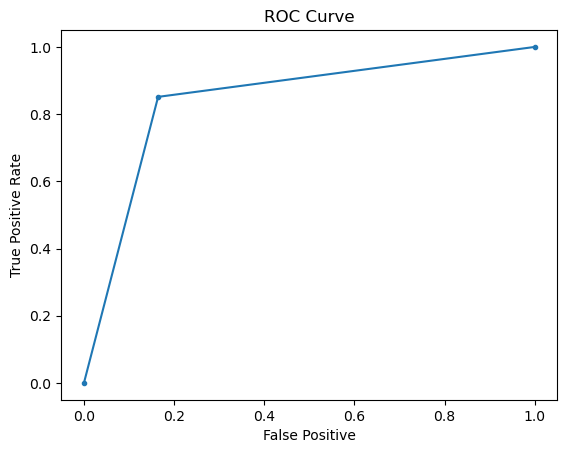

In [105]:
plot_roc_curve(dt_fpr,dt_tpr)